<a href="https://colab.research.google.com/github/yuvalmakan/FMNIST_Spyder/blob/main/fmnist_bonus_task_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries and DATA

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import matplotlib.pyplot as plt
import pickle

In [ ]:
# Reading the training CSV
df_train = pd.read_csv('fashion-mnist_train.csv')

# Extracting target labels
y_train = df_train['label'].values

# Dropping the label column
X_train = df_train.drop('label', axis=1).values

# Normalizing pixel values
X_train = X_train / 255.0

# Converting features to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

In [ ]:
# Reading the testing CSV
df_test = pd.read_csv('fashion-mnist_test.csv')

# Extracting labels and features
y_test = df_test['label'].values
X_test = df_test.drop('label', axis=1).values

# Normalizing pixel values
X_test = X_test / 255.0

# Converting to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# DataSet and DataLoader

In [ ]:
# Setting manual seed
torch.manual_seed(42)

In [ ]:
# Checking for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Defining custom Dataset class
class CustomDataset(Dataset):

  def __init__(self, X_data, X):
    # Initializing parent class
    super().__init__()
    # Storing features and labels
    self.X_data = X_data
    self.y_data = X

  def __len__(self):
    return len(self.X_data)

  def __getitem__(self, index):
    return self.X_data[index], self.y_data[index]

In [ ]:
# Defining hyperparameters
epochs = 50
lr = 0.002
batch_size = 128
momentum = 0.9

In [ ]:
# Instantiating dataset objects
train_dataset = CustomDataset(X_train_tensor, X_train_tensor)
test_dataset = CustomDataset(X_test_tensor, X_test_tensor)

In [ ]:
# Creating training and testing DataLoader
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=3, prefetch_factor=2, pin_memory=True)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=3, prefetch_factor=2, pin_memory=True)





# Making The Model Class and a few utilities

In [ ]:
# Defining neural network architecture
class Model(nn.Module):

  def __init__(self, num_inp_features):
    super().__init__()
    # Defining input layer
    self.linear1 = nn.Linear(num_inp_features, 320)
    self.linear2 = nn.Linear(320, 128)
    self.linear3 = nn.Linear(128, 320)

    # Defining output layer
    self.linearOut = nn.Linear(320, num_inp_features)

    # Defining activation function
    self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

  def forward(self, X):

    z1 = self.linear1(X)
    a1 = self.leaky_relu(z1)
    z2 = self.linear2(a1)
    a2 = self.leaky_relu(z2)
    z3 = self.linear3(a2)
    a3 = self.leaky_relu(z3)
    z4 = self.linearOut(a3)
    return z4

In [ ]:
# Instantiating the model
model = Model(784)

# Moving model to device
model = model.to(device)

# Defining loss function
loss_fn = nn.BCEWithLogitsLoss()

# Defining optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training our neural Network

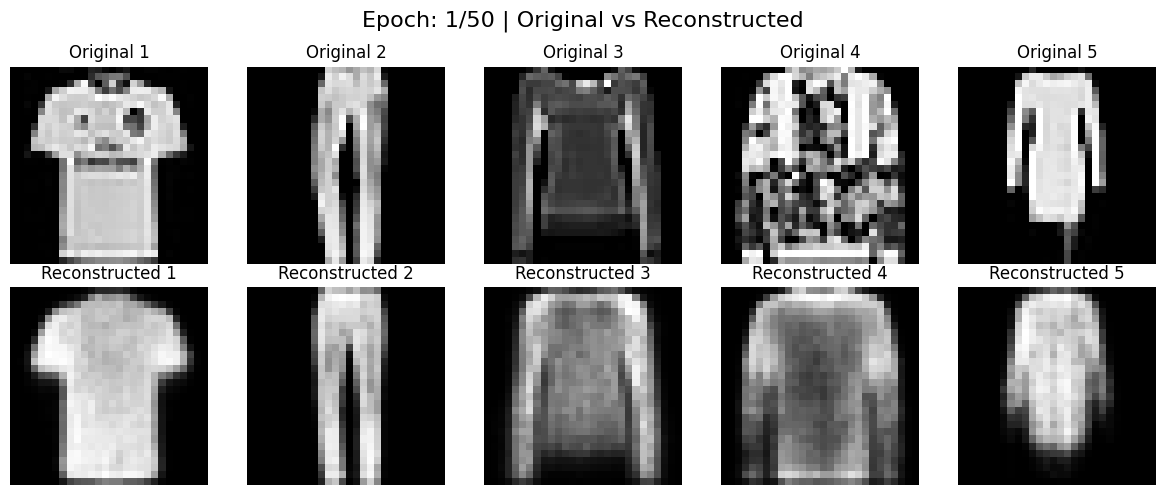

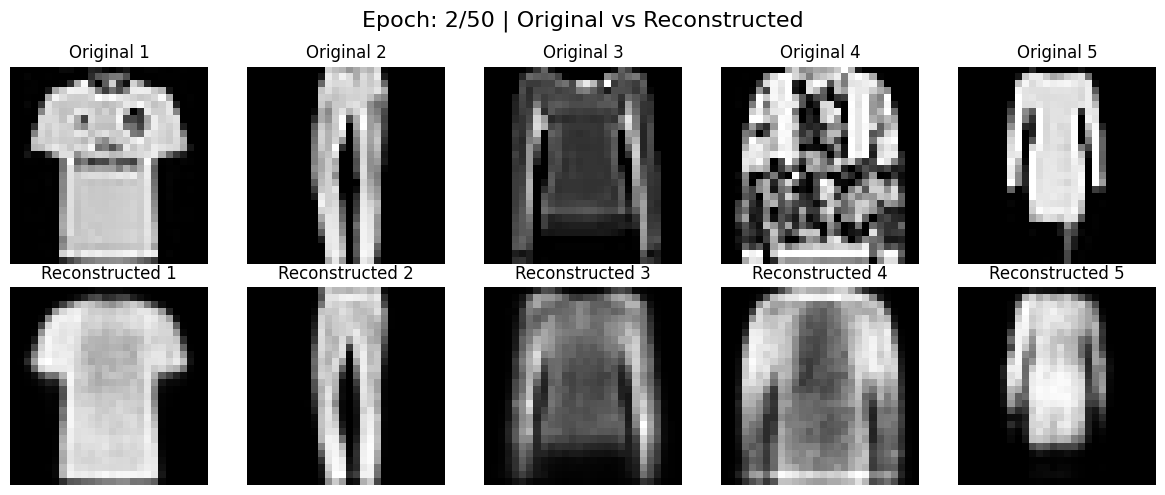

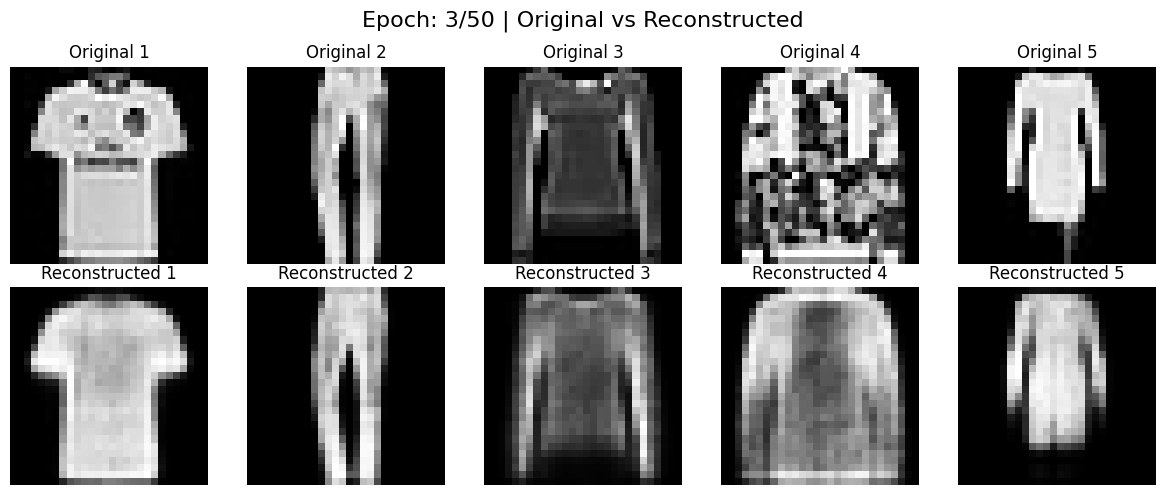

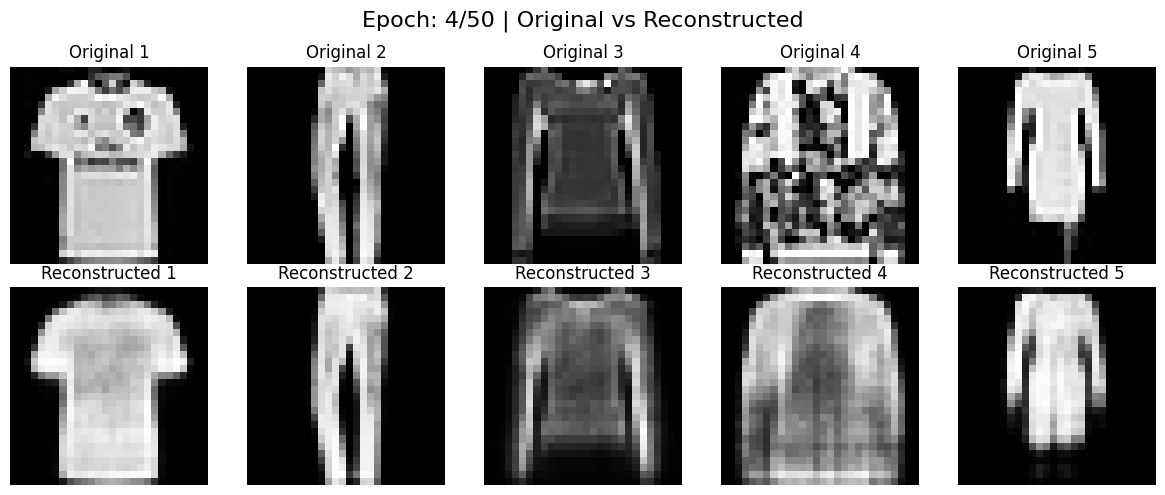

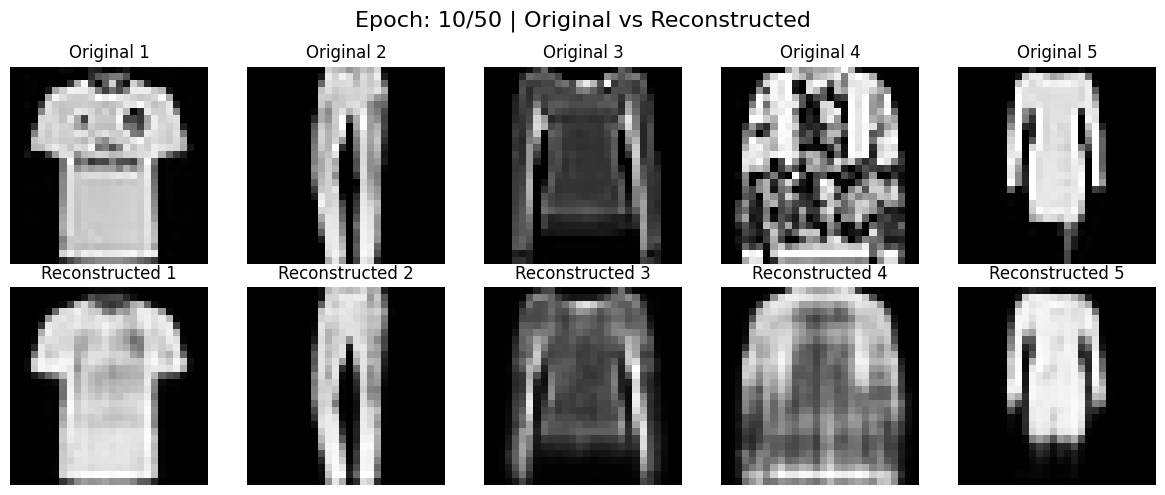

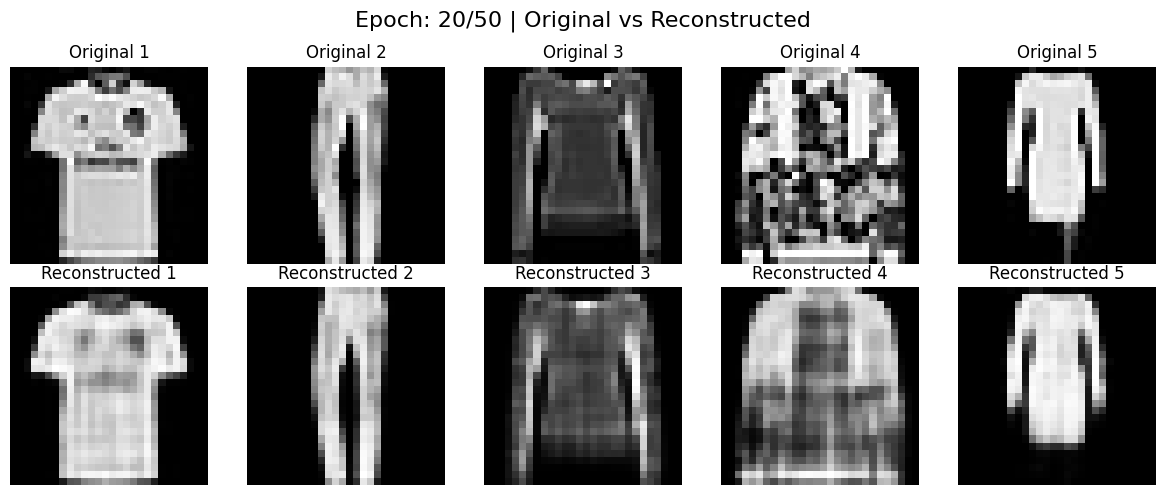

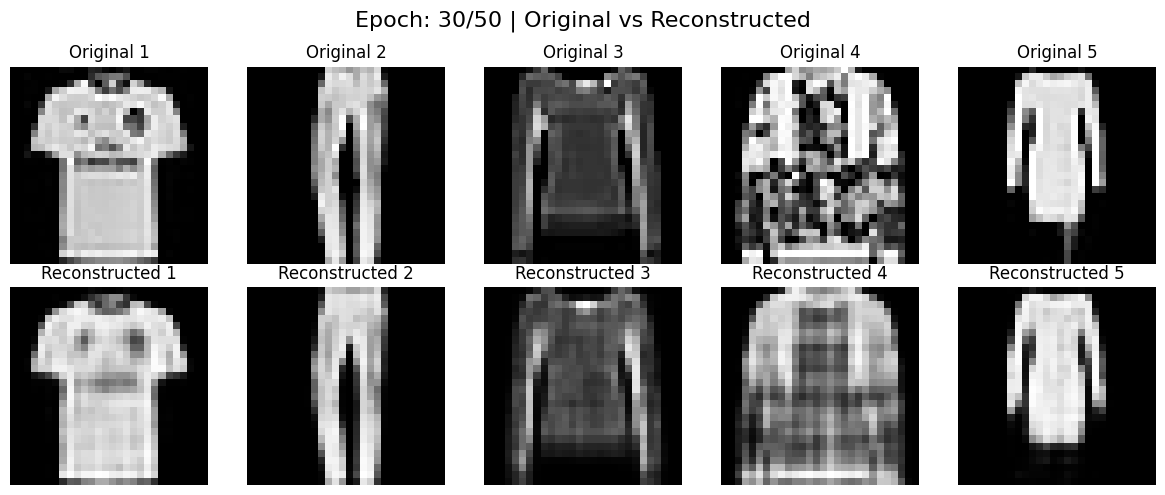

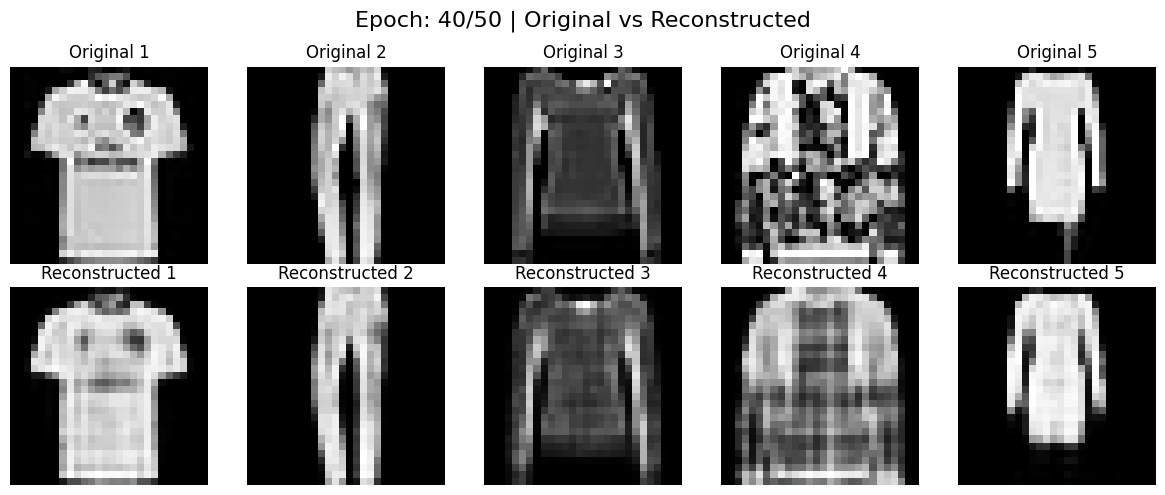

In [ ]:
# Grab the first 5 sample images from the test set before the loop starts
sample_features, _ = next(iter(test_data_loader))
sample_features = sample_features[:5].to(device)

# Starting training loop
for epoch in range(epochs):
    # Setting training mode
    model.train()

    # Iterating through training batches
    for batch_features, _ in train_data_loader:
        # Moving data to device
        batch_features = batch_features.to(device)

        # Getting model predictions (Reconstructing the input)
        y_pred = model(batch_features)

        # Calculating batch loss
        loss = loss_fn(y_pred, batch_features)

        # Clearing old gradients
        optimizer.zero_grad()

        # Calculating new gradients
        loss.backward()

        # Updating model weights
        optimizer.step()

    # Every 10 epochs, visualize the 5 clothes
    if (epoch + 1) % 10 == 0 or (epoch+1)<5:

        # Setting evaluation mode
        model.eval()

        # Disabling gradient tracking for evaluation
        with torch.no_grad():
            # Pass our 5 saved images through the autoencoder
            sample_outputs = model(sample_features)

            # Apply sigmoid to convert the raw logits back to [0,1] pixel ranges
            reconstructed_imgs = torch.sigmoid(sample_outputs).cpu().numpy()
            original_imgs = sample_features.cpu().numpy()

            # Create a 2x5 grid of subplots for visualization
            fig, axes = plt.subplots(2, 5, figsize=(12, 5))
            fig.suptitle(f"Epoch: {epoch+1}/{epochs} | Original vs Reconstructed", fontsize=16)

            for i in range(5):
                # Plot Original Images (Top Row)
                axes[0, i].imshow(original_imgs[i].reshape(28, 28), cmap='gray')
                axes[0, i].set_title(f"Original {i+1}")
                axes[0, i].axis('off')

                # Plot Reconstructed Images (Bottom Row)
                axes[1, i].imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
                axes[1, i].set_title(f"Reconstructed {i+1}")
                axes[1, i].axis('off')

            plt.tight_layout()
            plt.show()